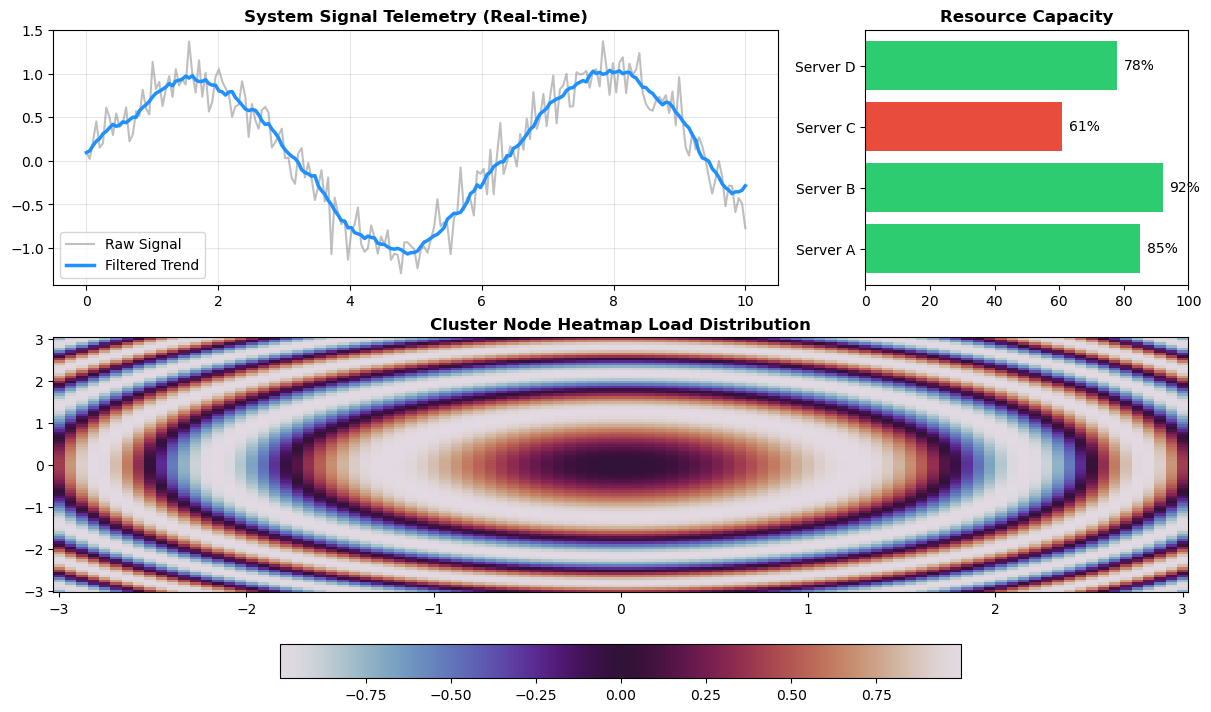

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# 1. Generate sophisticated dummy data
np.random.seed(42)
time = np.linspace(0, 10, 200)
signal = np.sin(time) + np.random.normal(0, 0.2, 200)
categories = ['Server A', 'Server B', 'Server C', 'Server D']
efficiency = [85, 92, 61, 78]

# 2. Setup the Canvas with a custom structural layout (GridSpec)
fig = plt.figure(figsize=(12, 7), layout='constrained')
gs = gridspec.GridSpec(2, 3, figure=fig) # A conceptual 2-row, 3-column grid

# Define our asymmetric axes using slicing
ax_main  = fig.add_subplot(gs[0, :2]) # Row 0, spans first two columns
ax_side  = fig.add_subplot(gs[0, 2])  # Row 0, spans last column
ax_wide  = fig.add_subplot(gs[1, :])  # Row 1, spans ALL columns

# --- CHART 1: Main Performance (Line with running average) ---
ax_main.plot(time, signal, color='gray', alpha=0.5, label='Raw Signal')
running_avg = np.convolve(signal, np.ones(10)/10, mode='same')
ax_main.plot(time, running_avg, color='dodgerblue', lw=2.5, label='Filtered Trend')
ax_main.set_title("System Signal Telemetry (Real-time)", weight='bold')
ax_main.legend()
ax_main.grid(True, alpha=0.3)

# --- CHART 2: Server Efficiency (Conditional Bar Chart) ---
# Programmatically color bars based on a performance threshold (e.g., < 70% is critical)
colors = ['#2ecc71' if x >= 70 else '#e74c3c' for x in efficiency]
bars = ax_side.barh(categories, efficiency, color=colors)
ax_side.set_xlim(0, 100)
ax_side.set_title("Resource Capacity", weight='bold')
# Add value labels to the ends of the horizontal bars
ax_side.bar_label(bars, fmt='%d%%', padding=5)

# --- CHART 3: Heatmap Distribution (Data Density) ---
# Generating a 2D Gaussian distribution to simulate a system load heatmap
x_mesh, y_mesh = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
z_mesh = np.sin(x_mesh**2 + y_mesh**2)
mesh_plot = ax_wide.pcolormesh(x_mesh, y_mesh, z_mesh, cmap='twilight', shading='auto')
ax_wide.set_title("Cluster Node Heatmap Load Distribution", weight='bold')
# Add an elegant nested color bar scale to the wide chart
fig.colorbar(mesh_plot, ax=ax_wide, orientation='horizontal', pad=0.1, shrink=0.6)

plt.show()

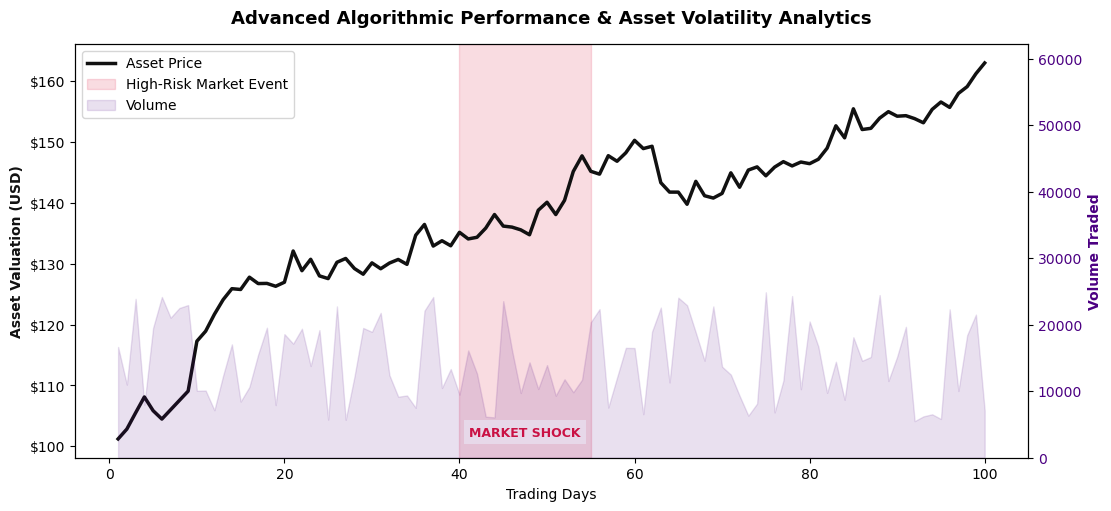

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Generate continuous timeline data
dates = np.arange(1, 101)
asset_price = 100 + np.cumsum(np.random.normal(0.5, 2, 100))
trading_volume = np.random.randint(5000, 25000, 100)

# 2. Setup the Base Canvas
fig, ax_price = plt.subplots(figsize=(11, 5), layout='constrained')

# 3. Create the Twin Axis for Volume
ax_volume = ax_price.twinx()

# 4. Plot Area Chart for Volume (Keep it subtly in the background using alpha)
ax_volume.fill_between(dates, trading_volume, color='indigo', alpha=0.12, label='Volume')
ax_volume.set_ylabel("Volume Traded", color='indigo', fontweight='semibold')
ax_volume.tick_params(axis='y', labelcolor='indigo')
ax_volume.set_ylim(0, max(trading_volume) * 2.5) # Squash volume down so it doesn't overlap price line spikes

# 5. Plot the Premium Price Line on top
ax_price.plot(dates, asset_price, color='#111111', lw=2.5, label='Asset Price')
ax_price.set_ylabel("Asset Valuation (USD)", color='#111111', fontweight='semibold')
ax_price.set_xlabel("Trading Days")

# Format the Price axis to display beautifully as currency
ax_price.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# 6. Advanced Customization: Highlight Anomaly/Crash Zones programmatically
# Let's say Day 40 to 55 experienced an economic flash-crash event
ax_price.axvspan(40, 55, color='crimson', alpha=0.15, label='High-Risk Market Event')

# Add a text callout inside the shaded risk zone
ax_price.text(47.5, min(asset_price), 'MARKET SHOCK', color='crimson', 
              weight='bold', fontsize=9, ha='center', va='bottom',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# 7. Unify legends from two different axes objects into a single box
lines_1, labels_1 = ax_price.get_legend_handles_labels()
lines_2, labels_2 = ax_volume.get_legend_handles_labels()
ax_price.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

ax_price.set_title("Advanced Algorithmic Performance & Asset Volatility Analytics", fontsize=13, weight='bold', pad=15)
plt.show()